In [27]:
from micrograd.engine import Value

In [28]:
a = Value(data = -4.0)
b = Value(data= 2.0)
c = a + b
d = a*b + b**3
c += c + 1
c += 1 + c - a
d += d*2 + (b + a).relu()
d += 3*d + (b-a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10 / f
print(g.data)
# g.backward()
print(a.grad)
print(b.grad)

24.70408163265306
0
0


In [29]:
a = Value(data = -4.0)
b = Value(data= 2.0)
c = a + b
d = a*b + b**3
c += c + 1
c += 1 + c - a
d += d*2 + (b + a).relu()
d += 3*d + (b-a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10 / f
print(g.data)
g.backward()
print(a.grad)
print(b.grad)

24.70408163265306
138.83381924198252
645.5772594752186


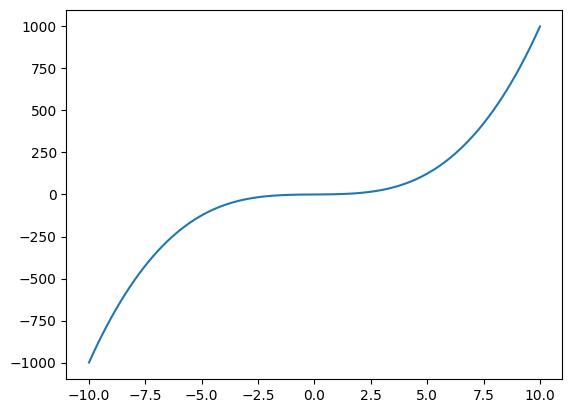

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x) + x**3

xs = np.linspace(-10,10,100)
ys = f(xs)
plt.plot(xs,ys)

In [31]:
x = 5
h = 0.00001
(f(x + h) - f(x)) / h

np.float64(75.28381697596842)

In [32]:
class Value:
    def __init__(self, data, _children = (), _op = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        return out
    

a = Value(3.0)
b = Value(-2.0)
a + b
a * b
c = Value(10.0)
d = a * b +c
d._prev ### 单下划线可以访问但是不建议
d._op 

'+'

In [33]:
from graphviz import Digraph


def trace(root):
    """
    从根节点递归遍历计算图，收集所有节点和边。
    返回: (nodes, edges)
    """
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """
    用 graphviz 可视化计算图。
    每个 Value 节点显示 data，操作节点显示操作符（+、* 等）。
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # 值节点：矩形框，显示 data
        dot.node(
            name=uid,
            label="{ data %.4f }" % (n.data,),
            shape='record'
        )

        # 如果是操作的结果，额外画一个操作符节点
        if n._op:
            op_uid = uid + n._op
            dot.node(name=op_uid, label=n._op)
            # 操作符节点 -> 值节点
            dot.edge(op_uid, uid)

    # 连接边：子节点 -> 父节点的操作符节点
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

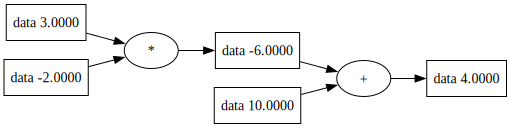

In [34]:
draw_dot(d) 

In [35]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        return out
    

a = Value(2.0, label = 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e +c; d.label = 'd'
f = Value(10.0, label= 'f')
L = d*f; L.label = 'L'
print(e.label)

e


In [36]:
from graphviz import Digraph


def trace(root):
    """
    从根节点递归遍历计算图，收集所有节点和边。
    返回: (nodes, edges)
    """
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """
    用 graphviz 可视化计算图。
    每个 Value 节点显示 data，操作节点显示操作符（+、* 等）。
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # 值节点：矩形框，显示 data
        dot.node(
            name=uid,
            label="{ %s  | data %.4f }" % (n.label, n.data),
            shape='record'
        )

        # 如果是操作的结果，额外画一个操作符节点
        if n._op:
            op_uid = uid + n._op
            dot.node(name=op_uid, label=n._op)
            # 操作符节点 -> 值节点
            dot.edge(op_uid, uid)

    # 连接边：子节点 -> 父节点的操作符节点
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

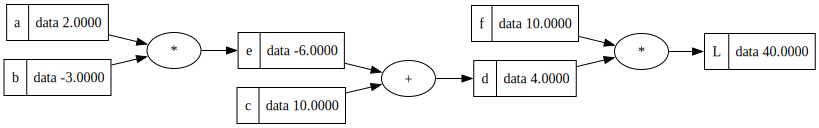

In [37]:
draw_dot(L)

## Backpropagation

In [38]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        return out
    

a = Value(2.0, label = 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e +c; d.label = 'd'
f = Value(-2.0, label= 'f')
L = d*f; L.label = 'L'
print(e.label)

e


In [39]:
from graphviz import Digraph


def trace(root):
    """
    从根节点递归遍历计算图，收集所有节点和边。
    返回: (nodes, edges)
    """
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    """
    用 graphviz 可视化计算图。
    每个 Value 节点显示 data，操作节点显示操作符（+、* 等）。
    """
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # 值节点：矩形框，显示 data
        dot.node(
            name=uid,
            label="{ %s  | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape='record'
        )

        # 如果是操作的结果，额外画一个操作符节点
        if n._op:
            op_uid = uid + n._op
            dot.node(name=op_uid, label=n._op)
            # 操作符节点 -> 值节点
            dot.edge(op_uid, uid)

    # 连接边：子节点 -> 父节点的操作符节点
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot 

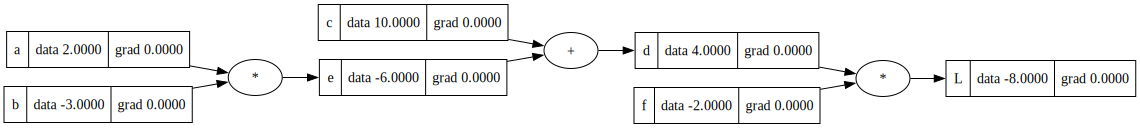

In [40]:
draw_dot(L)

In [41]:
def lol():

    h = 0.0001

    a = Value(2.0 + h, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0, label= 'f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0, label= 'f')
    L = d*f; L.label = 'L'
    L2 = L.data
    print((L1 - L2)/h)

     
    

In [42]:
lol()

6.000000000021544


In [43]:
def lol():

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0, label= 'f')
    L = d*f; L.label = 'L'
    L1 = L.data + h

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0, label= 'f')
    L = d*f; L.label = 'L'
    L2 = L.data
    print((L1 - L2)/h)

     

0.9999999999976694


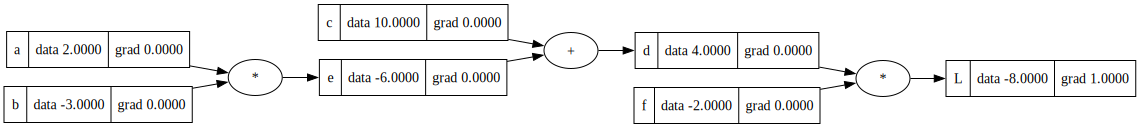

In [44]:
lol()
L.grad = 1
draw_dot(L)

L = d*f
dL / dd = f
====> 10


0.9999999999976694


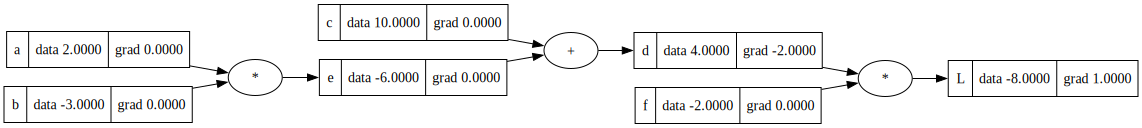

In [45]:
lol()
L.grad = 1
d.grad = -2
draw_dot(L)

In [46]:
def lol():

    h = 0.0001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0 + h, label= 'f')
    L = d*f; L.label = 'L'
    L1 = L.data 

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e +c; d.label = 'd'
    f = Value(-2.0, label= 'f')
    L = d*f; L.label = 'L'
    L2 = L.data
    print((L1 - L2)/h)

lol()

3.9999999999995595


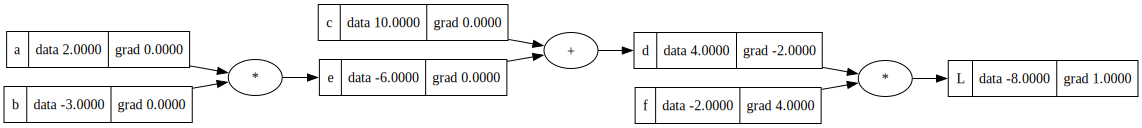

In [47]:
f.grad = 4
draw_dot(L)

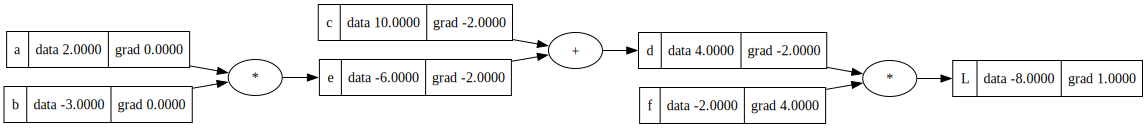

In [48]:
c.grad = -2
e.grad = -2
draw_dot(L)

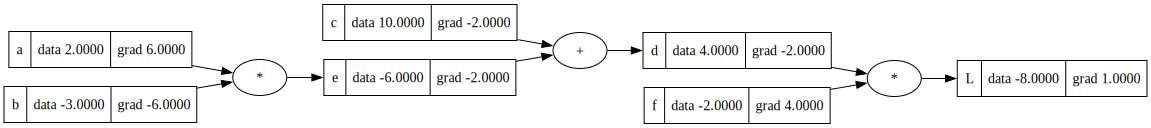

In [49]:
a.grad = 6
b.grad = -6
draw_dot(L)

## Forwardpass


In [50]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
d.data += 0.01*d.grad 

e = a*b
d = e +c
L = d*f
print(L.data)

-7.3528


## Neuron 

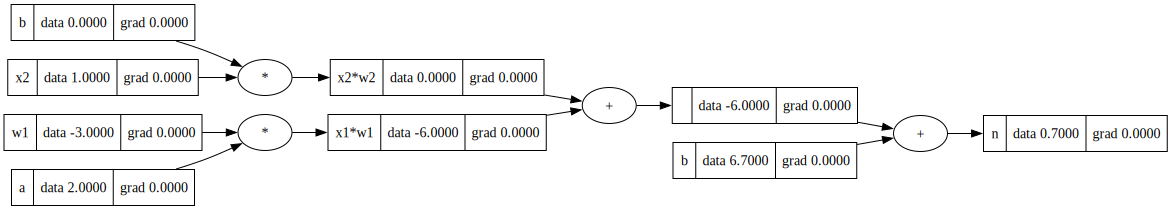

In [51]:
### inputs
x1 = Value(2.0, label = 'a')
x2 = Value(0.0,label='b')
### weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='x2')
### bias
b = Value(6.7, label='b')
### x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1 +x2w2 + b; n.label = 'n'
# o = n.tanh()
draw_dot(n)


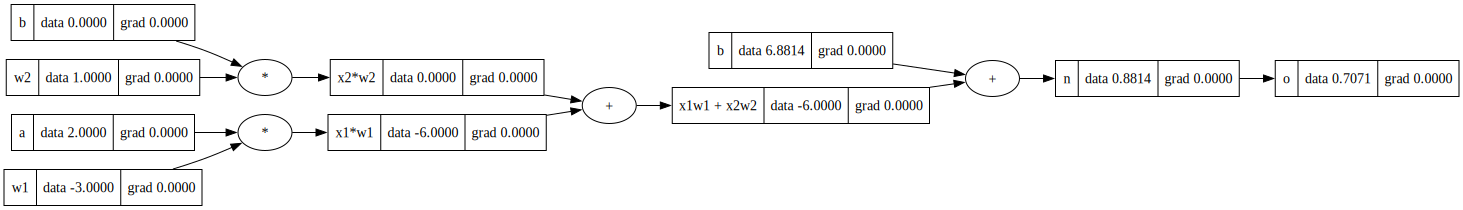

In [52]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh')
        return out
         
    
### inputs
x1 = Value(2.0, label = 'a')
x2 = Value(0.0,label='b')
### weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
### bias
b = Value(6.8813735870195432, label='b')
### x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' ### 
draw_dot(o)


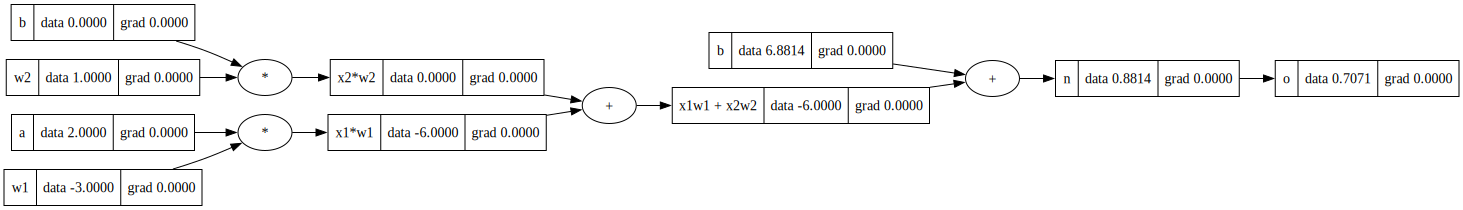

In [53]:
draw_dot(o)

In [54]:
o.grad = 1
n.grad = 1 - o.data**2
x1w1x2w2.grad = .5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.data
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

## 实现backward

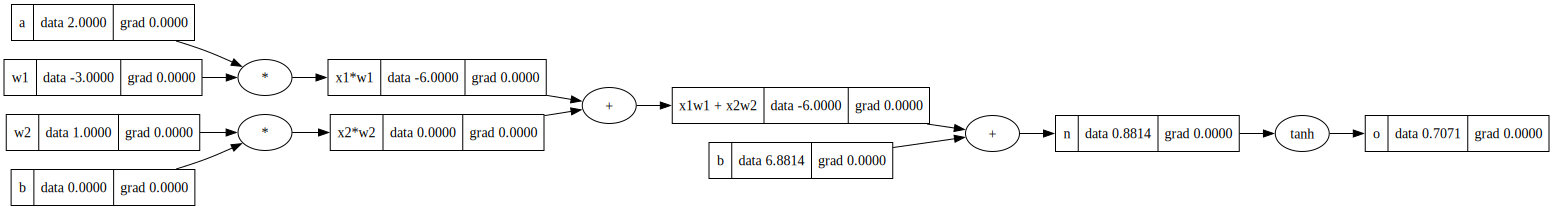

In [55]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev =set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        def _backward():
            self.grad = out.grad
            other.grad = out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh', _op = 'tanh')
        def _backward():
            self.grad = out.grad * (1 - t**2)
        out._backward = _backward
        return out
         
    
### inputs
x1 = Value(2.0, label = 'a')
x2 = Value(0.0,label='b')
### weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
### bias
b = Value(6.8813735870195432, label='b')
### x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' ### 
draw_dot(o)


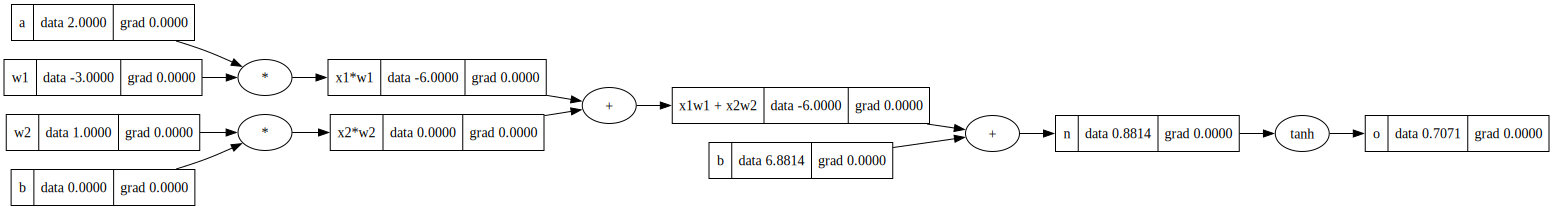

In [56]:
draw_dot(o)

In [57]:
o.grad = 1
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

## Topological 

In [58]:
topo = []
visited = set()
def build_loop(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_loop(child)
        topo.append(v)
build_loop(o)
topo


[Value (data = 1.0),
 Value (data = 0.0),
 Value (data = 0.0),
 Value (data = 2.0),
 Value (data = -3.0),
 Value (data = -6.0),
 Value (data = -6.0),
 Value (data = 6.881373587019543),
 Value (data = 0.8813735870195432),
 Value (data = 0.7071067811865476)]

### Automatic backward

In [59]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        def _backward():
            self.grad = out.grad
            other.grad = out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh', _op = 'tanh')
        def _backward():
            self.grad = out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_loop(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_loop(child)
                topo.append(v)
        build_loop(self)
        self.grad = 1.0
        print(topo)
        for node in reversed(topo):
            node._backward()
         
    
### inputs
x1 = Value(2.0, label = 'a')
x2 = Value(0.0,label='b')
### weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
### bias
b = Value(6.8813735870195432, label='b')
### x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o' ### 
draw_dot(o)
o.backward()

[Value (data = 6.881373587019543), Value (data = 1.0), Value (data = 0.0), Value (data = 0.0), Value (data = -3.0), Value (data = 2.0), Value (data = -6.0), Value (data = -6.0), Value (data = 0.8813735870195432), Value (data = 0.7071067811865476)]


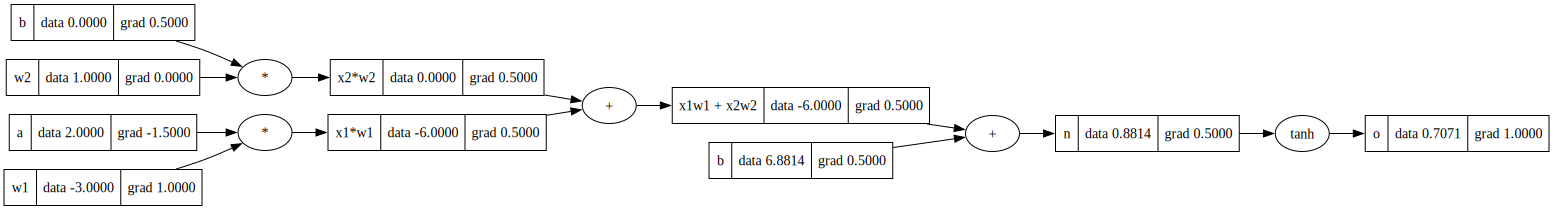

In [60]:
draw_dot(o)

## Bad case

[Value (data = 1), Value (data = 2)]


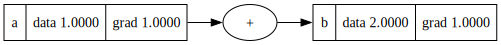

In [61]:
a = Value(1, label='a')
b = a + a; b.label = 'b'
draw_dot(b)
b.backward()
draw_dot(b)### which is wrong

[Value (data = 3), Value (data = -2), Value (data = -6), Value (data = 1), Value (data = -6)]


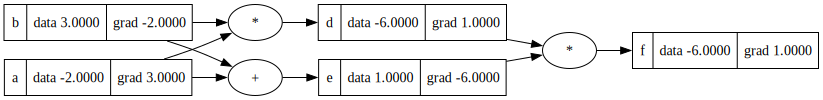

In [62]:
a = Value(-2, label='a')
b = Value(3, label='b')
d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'
draw_dot(f)
f.backward()
draw_dot(f)

In [63]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op = '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh', _op = 'tanh')
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_loop(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_loop(child)
                topo.append(v)
        build_loop(self)
        self.grad = 1.0
        print(topo)
        for node in reversed(topo):
            node._backward()

[Value (data = 3), Value (data = -2), Value (data = -6), Value (data = 1), Value (data = -6)]


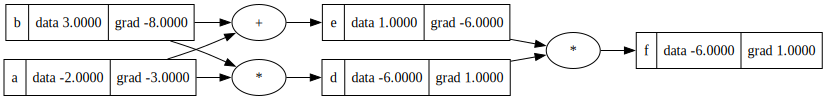

In [64]:
a = Value(-2, label='a')
b = Value(3, label='b')
d = a*b; d.label = 'd'
e = a+b; e.label = 'e'
f = d*e; f.label = 'f'
draw_dot(f)
f.backward()
draw_dot(f)

## Bad case

In [65]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), _op = '*') 
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __rmul__(self, other):
        return self*other
    def __truediv__(self, other):
        return self * (other**(-1))
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data **other, (self,), _op = f'**{other}')
        def _backward():
            self.grad += (other) * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * (-1)
    def __sub__(self, other):
        out = self +( - other)
        return out  
    def __rsub__(self, other):  # 支持 other - self
        return other + (-self)
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh', _op = 'tanh')
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x), _children=(self,), _op = 'exp')
        def _backward():
             self.grad += out.data * out.grad
        out._backward = _backward 
        return out
    def backward(self):
        topo = []
        visited = set()
        def build_loop(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_loop(child)
                topo.append(v)
        build_loop(self)
        self.grad = 1.0
        print(topo)
        for node in reversed(topo):
            node._backward()

In [66]:
a = Value(1, label= 'a')
a + 1
a*10

Value (data = 10)

In [67]:
10*a ### need __rmul__

Value (data = 10)

In [68]:
a.exp()

Value (data = 2.718281828459045)

In [69]:
### 定义除法 self/other
b = Value(4)
a / b

Value (data = 0.25)

In [70]:
### 定义减法 a-b
a - b

Value (data = -3)

[Value (data = 0.0), Value (data = 1.0), Value (data = 0.0), Value (data = 2.0), Value (data = -3.0), Value (data = -6.0), Value (data = -6.0), Value (data = 6.881373587019543), Value (data = 0.8813735870195432), Value (data = 2), Value (data = 1.7627471740390863), Value (data = 5.828427124746192), Value (data = -1), Value (data = 4.828427124746192), Value (data = 1), Value (data = 6.828427124746192), Value (data = 0.1464466094067262), Value (data = 0.7071067811865477)]


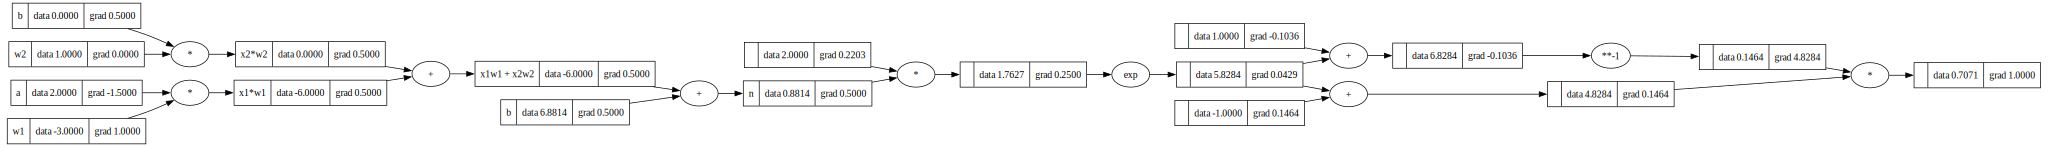

In [71]:
### inputs
x1 = Value(2.0, label = 'a')
x2 = Value(0.0,label='b')
### weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
### bias
b = Value(6.8813735870195432, label='b')
### x1*w1 + x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# ---
# o = n.tanh(); o.label = 'o' ### 
# ---

e =(2*n).exp()
o = (e - 1)/ (e + 1)

draw_dot(o)
o.backward()
draw_dot(o)

### use Pytorch api to achieve same result

In [72]:
import torch 
x1 = torch.tensor([2],dtype=torch.double); x1.requires_grad = True
w1 = torch.tensor([-3],dtype=torch.double); w1.requires_grad = True
x2 = torch.tensor([0],dtype=torch.double); x2.requires_grad = True
w2 = torch.tensor([1],dtype=torch.double); w2.requires_grad = True
b = torch.tensor([6.8813735870195432],dtype=torch.double); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
o.backward()
print(w1.grad.item())
 

0.9999999999999999


### MLP

In [149]:
import math
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None

    def __repr__(self):
        return f'Value (data = {self.data})' ### 这样可以避免打印实例 只要打印实例就打印return的内容

    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), _op = '+') ### 这里再次实例化
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), _op = '*') 
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __rmul__(self, other):
        return self*other
    def __truediv__(self, other):
        return self * (other**(-1))
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data **other, (self,), _op = f'**{other}')
        def _backward():
            self.grad += (other) * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * (-1)
    def __sub__(self, other):
        out = self +( - other)
        return out  
    def __rsub__(self, other):  # 支持 other - self
        return (-self) + other 
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), label='tanh', _op = 'tanh')
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x), _children=(self,), _op = 'exp')
        def _backward():
             self.grad += out.data * out.grad
        out._backward = _backward 
        return out
    def backward(self):
        topo = []
        visited = set()
        def build_loop(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_loop(child)
                topo.append(v)
        build_loop(self)
        self.grad = 1.0
        # print(topo)
        for node in reversed(topo):
            node._backward()
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def parameters(self):
        return self.w + [self.b] ### 列表相加
    def __call__(self, x):
        act = sum(([wi*xi for wi, xi in zip(x, self.w)]), start= self.b)
        out = act.tanh()
        return out
x = [2.0, 3.0]
n = Neuron(2)
n(x)        

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs
x = [2.0, 3.0]
layer = Layer(3,10)
layer(x)

class MLP: 
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    def parameters(self):
        return  [p for layer in self.layers for p in layer.parameters()]
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x 
x = [2.0,3.0,-1.0]
mlp = MLP(3,[4,4,1])
mlp(x)

Value (data = 0.13036886954965637)

In [150]:
xs = [[2,3,-1],
      [3,-1,0.5],
      [0.5,1,1],
      [1,1,-1]]
ys = [1,-1,-1,1]
ypred = [mlp(x) for x in xs]
print(ypred)

[Value (data = 0.13036886954965637), Value (data = 0.01328056924099873), Value (data = 0.6261549712250195), Value (data = 0.15458499478831522)]


In [151]:
loss = sum([(y1 - y2)**2 for y1,y2 in zip(ypred, ys)], start= Value(0))
print(loss)
loss.backward()
mlp.layers[0].neurons[0].w[0].grad
mlp.layers[0].neurons[0].w[0].data

Value (data = 5.142102336526622)


-0.04271080641024683

In [152]:
mlp.parameters()[1].grad

0.31357810665492647

In [ ]:
# mlp.parameters()
for k in range(200):
    ypred = [mlp(x) for x in xs]
    loss = sum([(y1 - y2)**2 for y1,y2 in zip(ypred, ys)], start= Value(0))
    loss.backward()
    for p in mlp.parameters(): ### 梯度归零
        p.data = 0
    for p in mlp.parameters():
        p.data -= 0.01 * p.grad   
    print(k, f'loss is {loss.data}')

0 loss is 0.4396859650350431
1 loss is 0.4157049153559956
2 loss is 0.39359524976340265
3 loss is 0.37318798541485065
4 loss is 0.354329303635601
5 loss is 0.336879582747321
6 loss is 0.32071235395855463
7 loss is 0.3057132351005096
8 loss is 0.2917788804235609
9 loss is 0.27881597191946306
10 loss is 0.266740268061351
11 loss is 0.2554757188378484
12 loss is 0.244953650945537
13 loss is 0.23511202352697153
14 loss is 0.2258947525171016
15 loss is 0.21725110018591753
16 loss is 0.2091351256039422
17 loss is 0.20150519133045697
18 loss is 0.19432352149761348
19 loss is 0.1875558065375772
20 loss is 0.1811708500024273
21 loss is 0.17514025320596513
22 loss is 0.1694381337366253
23 loss is 0.16404087422621189
24 loss is 0.15892689809357832
25 loss is 0.15407646930474483
26 loss is 0.1494715134948188
27 loss is 0.14509545807883975
28 loss is 0.1409330892367669
29 loss is 0.1369704238920959
30 loss is 0.13319459501472317
31 loss is 0.1295937487679109
32 loss is 0.12615695218812234
33 loss i